# 03 — Hull–White Calibration

**Goal:** calibrate the one-factor Hull–White model to the ATM swaption matrix and inspect residual model error.

We keep two parameters:

- `a`: mean reversion
- `sigma`: short-rate volatility

Because the model has only two free parameters but many calibration instruments, a perfect fit should not be expected.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql

from src.rates_project import *
set_evaluation_date()
print("QuantLib version:", ql.__version__)
print("Evaluation date:", ql.Settings.instance().evaluationDate)

QuantLib version: 1.43
Evaluation date: January 15th, 2026


In [2]:
curve, curve_handle, _ = build_curve()
helpers, swaption_meta = build_swaption_helpers(curve_handle)
model = calibrate_hull_white(curve_handle, helpers)
a, sigma = [float(x) for x in model.params()]
print(f"Calibrated a     = {a:.8f}")
print(f"Calibrated sigma = {sigma:.8f}")

Calibrated a     = 0.00005066
Calibrated sigma = 0.00563854


## 1. Market vs model

In [3]:
calib = calibration_table(model, swaption_meta)
calib

,swaption,market_vol,model_implied_vol,vol_error_bp,market_value,model_value,relative_price_error
0,1Yx1Y,0.235,0.243202,82.015049,0.002113,0.002186,0.034730
1,1Yx2Y,0.230,0.238398,83.979808,0.004181,0.004333,0.036342
2,1Yx5Y,0.223,0.225021,20.208167,0.010311,0.010404,0.009023
3,1Yx10Y,0.218,0.214797,-32.032851,0.019762,0.019473,-0.014637
4,2Yx1Y,0.232,0.234914,29.140995,0.002999,0.003037,0.012445
5,2Yx2Y,0.227,0.227717,7.172391,0.005955,0.005974,0.003132
6,2Yx5Y,0.220,0.219935,-0.645937,0.014364,0.014360,-0.000291
7,2Yx10Y,0.215,0.212179,-28.208952,0.027202,0.026848,-0.013021
8,5Yx1Y,0.224,0.213908,-100.922849,0.004632,0.004427,-0.044179
9,5Yx2Y,0.219,0.213855,-51.452451,0.008979,0.008772,-0.023043


In [4]:
calibration_summary(calib)

mean_abs_vol_error_bp             39.511144
max_abs_vol_error_bp             100.922849
mean_abs_relative_price_error      0.017379
dtype: float64

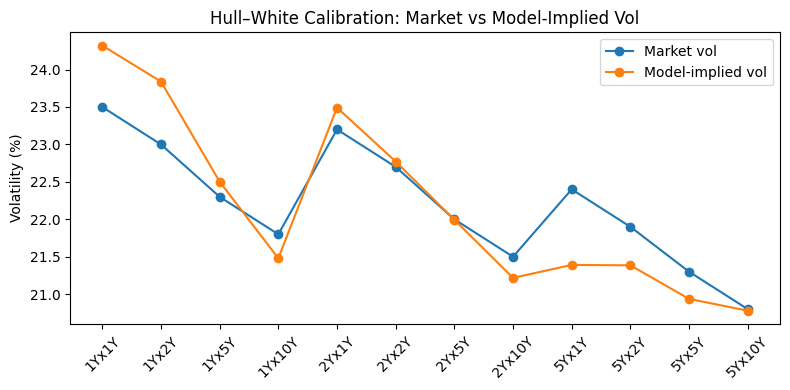

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(calib))
ax.plot(x, calib["market_vol"] * 100, marker="o", label="Market vol")
ax.plot(x, calib["model_implied_vol"] * 100, marker="o", label="Model-implied vol")
ax.set_xticks(x, calib["swaption"], rotation=45)
ax.set_ylabel("Volatility (%)")
ax.set_title("Hull–White Calibration: Market vs Model-Implied Vol")
ax.legend()
plt.tight_layout()
plt.show()